# Lab: SVMs
## CMSE 381 - Spring 2022
## April 15, 2022

![](https://upload.wikimedia.org/wikipedia/commons/thumb/7/72/SVM_margin.png/300px-SVM_margin.png)

##ANSWER## 

*Instructor notes:*

Made use of these python translations
- [SVM lab](https://www.science.smith.edu/~jcrouser/SDS293/labs/lab15-py.html)





In [5]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import time


# ML imports we've used previously
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



In this module we are going to test out the SVM methods discussed in class. The books definitions as we talked about in class are:

- *Maximal Margin Classifiers*, where the goal was to find a separating hyperplane with no misclassifications, 
- *Support vector classifiers*, where we allow for a soft margin and hence some correct issues, but only allow for a linear kernal, and 
- *Support vecotr machines*, where we have a soft margin and an option for kernels. 

It turns out that `sklearn` has only one function to do all of this, and we can basically trick it (by understanding the innards) into doing any of them.  **<font color=red>However, there are two things that will likely be confusing. </font>**
- The command is just called `SVC`, but you should thinking of it as doing the most general SVM as defined in the book and then we can modify our inputs to allow for the other options as necessary.
- The cost input parameter is not the same as the `C` defined in the book. 

In [6]:
##ANSWER##



# Generating random data: 20 observations of 2 features and divide into two classes.
# Save the file as a csv and include with the lab
np.random.seed(5)
n = 50
X = np.random.randn(n,2)
y = np.repeat([1,-1], n/2) # 
X[y == -1] = X[y == -1]+2

data = np.concatenate((X,y.reshape(-1,1)), axis = 1)
np.random.shuffle(data)


# UNCOMMENT to save the data file in the folder.
# np.savetxt('SVM-Data.csv',data)

For now, we're going to mess with some synthetic data (meaning I generated it and saved it as a CSV for you). 

In [7]:
data = np.loadtxt('SVM-Data.csv')

X = data[:,:2]
y = data[:,2]

Text(0, 0.5, 'X2')

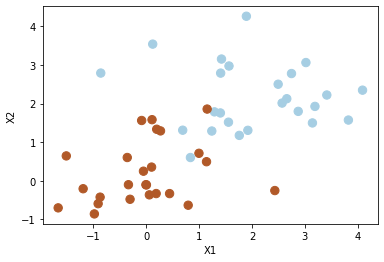

In [8]:
plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=mpl.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2')

And then, tada! Here's all it takes to fit your support vector machine. 

In [9]:
from sklearn.svm import SVC


In [10]:
svc = SVC(C=1, kernel='linear', )
svc.fit(X, y)

SVC(C=1, kernel='linear')

&#9989; **<font color=red>Do this:</font>** Use your trained model to figure out the equation of the hyperplane. Plot it on a graph with the data points.  Does the resulting hyperplane seem reasonable? 

In [11]:
# Your code here 


In [12]:
##ANSWER##

beta = np.round(svc.coef_,2)
beta_int = np.round(svc.intercept_,2)

print('Equation of hyperplane:')
print( f"{beta_int[0]} + {beta[0,0]}*X_1 +{beta[0,1]}*X_2 =0")


Equation of hyperplane:
3.29 + -1.2*X_1 +-1.54*X_2 =0


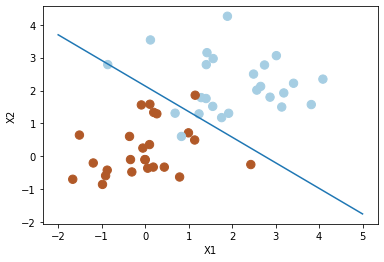

In [13]:
##ANSWER##
plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=mpl.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2')

w = svc.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(-2, 5)
yy = a * xx - (svc.intercept_[0]) / w[1]

plt.plot(xx,yy)

Remember that the SVM setting only uses a subset of observations, called *support vectors* to actually determine this hyperplane. The `svc` object keeps track of those for us. 

In [14]:
# Here are the indices of the support vectors from our original X matrix

svc.support_

array([18, 22, 32, 33, 39, 42, 44,  0, 21, 27, 30, 31, 40, 47],
      dtype=int32)

In [15]:
# It also keeps track of the points themselves 
svc.support_vectors_

array([[-0.85968797,  2.7893664 ],
       [ 1.28953355,  1.7848122 ],
       [ 1.23923969,  1.28883677],
       [ 0.83529809,  0.60292598],
       [ 1.55457001,  1.51787981],
       [ 0.68922687,  1.31043477],
       [ 1.75928886,  1.17587655],
       [ 0.99643983,  0.71242127],
       [ 2.43077119, -0.25209213],
       [ 0.19766009,  1.33484857],
       [ 0.26961241,  1.29196338],
       [ 0.10960984,  1.58248112],
       [-0.08687561,  1.56153229],
       [ 1.15139101,  1.85733101]])

&#9989; **<font color=red>Do this:</font>** Draw a scatter plot of these points on top of the drawing you've already been building.  Do these points make sense to be the support vectors?

In [16]:
# Your code here 


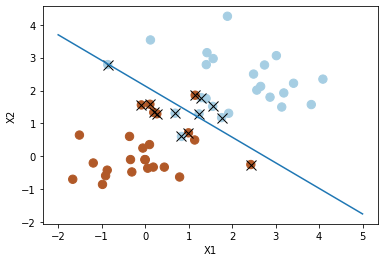

In [17]:
##ANSWER##
plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=mpl.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2')

w = svc.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(-2, 5)
yy = a * xx - (svc.intercept_[0]) / w[1]

plt.plot(xx,yy)

# Support vectors indicated in plot by X's
sv = svc.support_vectors_
plt.scatter(sv[:,0], sv[:,1], c='k', marker='x', s=100, linewidths=1)


Now that you have a sense of what's going on in the svc function, I've built you a function that will make this nice drawing for us without much effort.  We can hand it our `X` and `y` data, along with the trained `svc` to get the plot, with some added stuff, including dashed lines for the margin and colors for which side of the hyperplane you're on (blue for -1, red for +1).

In [18]:
# Run this cell to define the function
def plot_svc(svc, X, y, h=0.02, pad=0.25):
    x_min, x_max = X[:, 0].min()-pad, X[:, 0].max()+pad
    y_min, y_max = X[:, 1].min()-pad, X[:, 1].max()+pad
    xvec = np.arange(x_min, x_max, h)
    yvec = np.arange(y_min, y_max, h)
    xx, yy = np.meshgrid(xvec,yvec )
    
    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.2)

    plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=mpl.cm.Paired)
    # Support vectors indicated in plot by X's
    sv = svc.support_vectors_
    plt.scatter(sv[:,0], sv[:,1], c='k', marker='x', s=100, linewidths=1)
    
    if svc.kernel == 'linear':
        # Get the margin lines 
        w = svc.coef_[0]
        a = -w[0] / w[1]
        yhyperplane = a * xvec - (svc.intercept_[0]) / w[1]
        margin = 1 / np.sqrt(np.sum(svc.coef_ ** 2))
        ymargin_down = yhyperplane+  - np.sqrt(1 + a ** 2) * margin
        ymargin_up = yhyperplane + np.sqrt(1 + a ** 2) * margin
        plt.plot(xvec,ymargin_down, "k--")
        plt.plot(xvec,ymargin_up, "k--")

    
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()
    print('Number of support vectors: ', svc.support_.size)



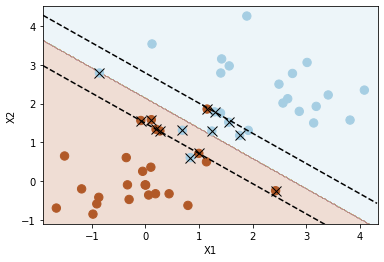

Number of support vectors:  14


In [19]:
#From here on, you can just use this command to plot.
plot_svc(svc, X, y)


## Messing with $C$

Below we have the model fit using several choices for $C$

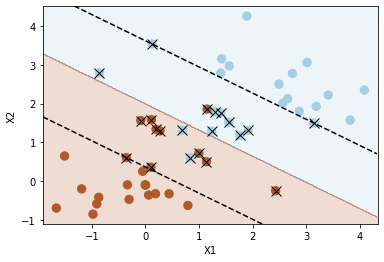

Number of support vectors:  21


In [20]:
svc = SVC(C=10e-2, kernel='linear', )
svc.fit(X, y)
plot_svc(svc, X, y)


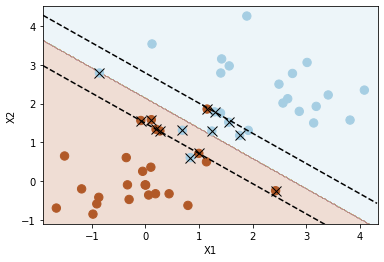

Number of support vectors:  14


In [21]:
svc = SVC(C=1, kernel='linear', )
svc.fit(X, y)
plot_svc(svc, X, y)


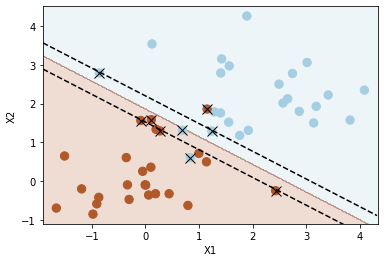

Number of support vectors:  9


In [22]:
svc = SVC(C=10e5, kernel='linear', )
svc.fit(X, y)
plot_svc(svc, X, y)


Note that [fix this for next year!!!]()
- The cost $C$ in class had the property that big $C$ meant small margin 
- This is a DIFFERENT $C$. In this case, big $C$ means small margin. 

They're both serving the same purpose, i.e. to control how tolerant we are to misclassifications. 

The following code uses some nice functions in `sklearn` to do a CV test to determine the best $C$.

In [23]:
from sklearn.model_selection import GridSearchCV


In [24]:
# Select the optimal C parameter by cross-validation
C_list = [0.001, 0.01, 0.1, 1, 5, 10, 100]
tuned_parameters = [{'C': C_list}]
clf = GridSearchCV(SVC(kernel='linear'), tuned_parameters, cv=10, scoring='accuracy')
clf.fit(X, y)

GridSearchCV(cv=10, estimator=SVC(kernel='linear'),
             param_grid=[{'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}],
             scoring='accuracy')

&#9989; **<font color=red>Do this:</font>** Use the `clf.cv_results_` function to determine which $C$ give the best score (note there could be ties). Which $C$ did the function choose? 

In [25]:
# Your code here

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_C', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])
[0.4  0.92 0.94 0.92 0.92 0.94 0.94]
model pick: {'C': 0.1}


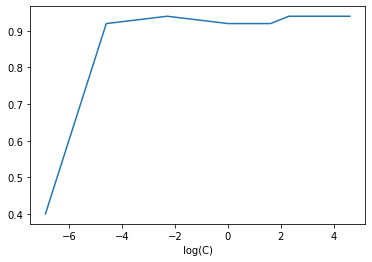

In [26]:
##ANSWER##

print(clf.cv_results_.keys())

plt.plot(np.log(C_list),clf.cv_results_['mean_test_score'])
plt.xlabel('log(C)')

print(clf.cv_results_['mean_test_score'])
print('model pick:', clf.best_params_)

&#9989; **<font color=red>Do this:</font>** Load in the `SVM-Data2.csv` data from the folder. Run this same analysis again, namily: 
- Use the `GridSearchCV` function to determine the best choice of $C$.
- Train an individual `SVC` instance with $C$ set to that value.  Then you can draw the resulting model with the `plot_svc` function from earlier. How does the model do?

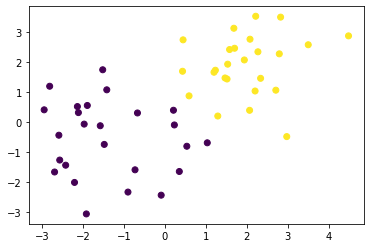

In [27]:
##ANSWER##


# Generating random data: 50 observations of 2 features and divide into two classes.
# Save the file as a csv and include with the lab
# This one is more spread about than original
np.random.seed(48824)
n = 50
X = np.random.randn(n,2)
y = np.repeat([1,-1], n/2) # 
X[y == -1] = X[y == -1]+2
X[y == 1] = X[y == 1]-1.5
X[:,1][y == 1] = X[:,1][y == 1]+.9
y = y*-1



data = np.concatenate((X,y.reshape(-1,1)), axis = 1)
np.random.shuffle(data)

plt.scatter(data[:,0],data[:,1], c = data[:,2])


# UNCOMMENT to save the data file in the folder.
# np.savetxt('SVM-Data2.csv',data)

In [28]:
##ANSWER##

data2 = np.loadtxt('SVM-Data2.csv')
X = data2[:,:2]
y = data2[:,2]

# Select the optimal C parameter by cross-validation
C_list = [0.001, 0.01, 0.1, 1, 5, 10, 100]
tuned_parameters = [{'C': C_list}]
clf = GridSearchCV(SVC(kernel='linear'), tuned_parameters, cv=10, scoring='accuracy')
clf.fit(X, y)
clf.best_params_

{'C': 0.01}

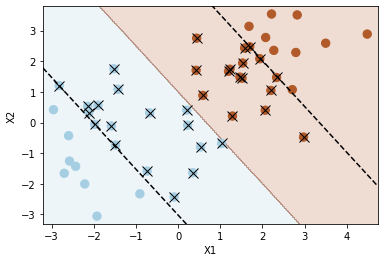

Number of support vectors:  33


In [30]:
##ANSWER##
svc = SVC(C=0.01, kernel='linear', )
svc.fit(X, y)
plot_svc(svc, X, y)


# Swapping out the kernel 

(100, 2)
(100,)


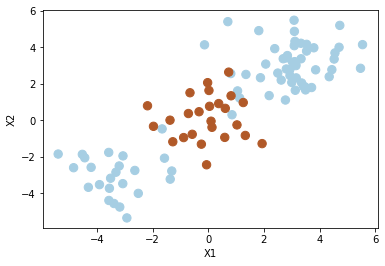

In [31]:
##ANSWER##
# More data generation 


np.random.seed(8)
n = 100
k = int(n/4)
X = np.random.randn(n,2)
X[:2*k] = X[:2*k] +3
X[2*k+1:3*k] = X[2*k+1:3*k] -3
print(X.shape)
y = np.concatenate([np.repeat(-1, 3*k), np.repeat(1,n-3*k)])
print(y.shape)

data = np.concatenate((X,y.reshape(-1,1)), axis = 1)


plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=mpl.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2')

np.savetxt('SVM-Data3.csv',data)

Text(0, 0.5, 'X2')

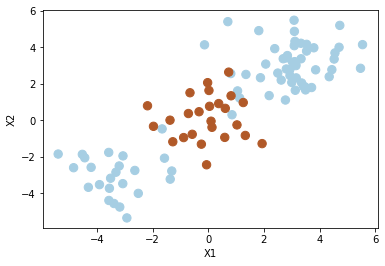

In [32]:
data3 = np.loadtxt('SVM-Data3.csv')
X = data3[:,:2]
y = data3[:,2]


plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=mpl.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2')

&#9989; **<font color=red>Do this:</font>** Train a SVC using a radial kernel (this is 'rbf' in this code) and with $C=1$, $\gamma = 1$. Use the `plot_svc` function to see what the learned boundary looks like. 

In [33]:
# Your code here

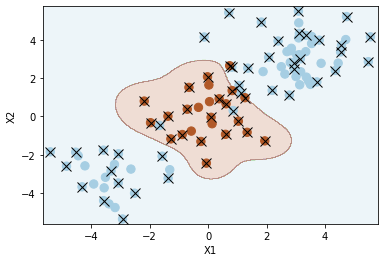

Number of support vectors:  60


In [34]:
##ANSWER##
svm = SVC(C=1.0, kernel='rbf', gamma=1)
svm.fit(X, y)
plot_svc(svm, X, y)

&#9989; **<font color=red>Do this:</font>** What happens if you increase $C$ to 100? Is this model looking better or worse than what you had before?

In [35]:
# Your code here #

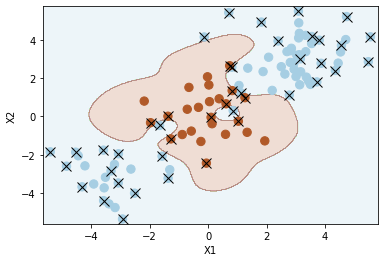

Number of support vectors:  43


In [39]:
##ANSWER##
# Increasing C parameter, allowing more flexibility
svm2 = SVC(C=100, kernel='rbf', gamma=1.0)
svm2.fit(X,y)
plot_svc(svm2, X,y)

# This is worse because we're heading for overfitting land.

&#9989; **<font color=red>Do this:</font>** Use the `GridSearchCV` function to determine the best $C$ and $\gamma$ parameters

In [40]:
##ANSWER##
tuned_parameters = [{'C': [0.01, 0.1, 1, 10, 100],
                     'gamma': [0.5, 1,2,3,4]}]
clf = GridSearchCV(SVC(kernel='rbf'), tuned_parameters, cv=10, scoring='accuracy')
clf.fit(X, y)
clf.best_params_

{'C': 1, 'gamma': 0.5}

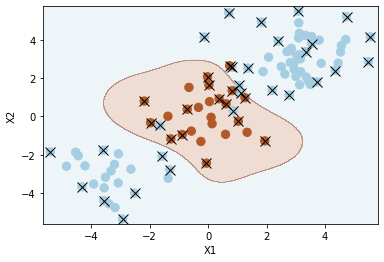

Number of support vectors:  43


In [41]:
##ANSWER##
svm = SVC(C=1.0, kernel='rbf', gamma=0.5)
svm.fit(X, y)
plot_svc(svm, X, y)

# Still have time? 

Download the NIST data set from here: https://archive.ics.uci.edu/ml/datasets/optical+recognition+of+handwritten+digits

You just need two files for now, the training set `optdigits.tra` and the testing set `optdigits.tes`.

In [42]:
X_train = pd.read_csv('optdigits.tra', header=None)
y_train = X_train[64]
X_train = X_train.drop(X_train.columns[64], axis=1)

X_test = pd.read_csv('optdigits.tes', header=None)
y_test = X_test[64]
X_test = X_test.drop(X_test.columns[64], axis=1)

In [43]:
print(X_train.shape)
print(X_test.shape)

(3823, 64)
(1797, 64)


This data set consists of 8x8 images of handwritten digits. Mess around with the value of $i$ below to see other examples

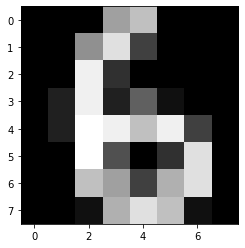

Data point 27 is labeled as 6


In [44]:
i = 27
plt.imshow(X_train.values[i].reshape(8,8), cmap="gray") 
plt.show()
print(f'Data point {i} is labeled as {y_train[i]}')

&#9989; **<font color=red>Do this:</font>** Build a classifier to predict the correct digit for a given handwritten digit. As you do this, answer the following questions:
- What choice of kernel does best? 
- What are the optimal choices of parameters for the SVC? 
- How well does your classifier do? Don't forget that quality measures should always use testing data.

In [45]:
# Your answer here

In [46]:
##ANSWER##
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

# Print a nice confusion matrix
cm = confusion_matrix(y_train, svc.predict(X_train))
cm_df = pd.DataFrame(cm.T, index=svc.classes_, columns=svc.classes_)
print(cm_df)

     0    1    2    3    4    5    6    7    8    9
0  376    0    0    0    0    0    0    0    0    0
1    0  389    0    0    0    0    0    0    0    0
2    0    0  380    0    0    0    0    0    0    0
3    0    0    0  389    0    0    0    0    0    0
4    0    0    0    0  387    0    0    0    0    0
5    0    0    0    0    0  376    0    0    0    0
6    0    0    0    0    0    0  377    0    0    0
7    0    0    0    0    0    0    0  387    0    0
8    0    0    0    0    0    0    0    0  380    0
9    0    0    0    0    0    0    0    0    0  382


In [47]:
##ANSWER##
cm = confusion_matrix(y_test, svc.predict(X_test))
print(pd.DataFrame(cm.T, index=svc.classes_, columns=svc.classes_))

     0    1    2    3    4    5    6    7    8    9
0  177    0    0    1    0    0    0    0    0    1
1    0  178    7    0    0    0    0    0    9    0
2    0    0  170    5    0    1    0    0    1    0
3    0    0    0  171    0    0    0    0    5    4
4    0    0    0    0  180    0    1    1    0    1
5    1    0    0    2    0  180    0    7    2    3
6    0    3    0    0    0    0  179    0    0    0
7    0    0    0    2    0    0    0  165    0    0
8    0    1    0    1    1    0    1    0  157    1
9    0    0    0    1    0    1    0    6    0  170


# Lab Survey

To get credit for today's lab, fill out the following survey before the end of class:

https://forms.gle/hX8GT5FJ2fNMeTo1A

Note this is the same link for every lab, so you will fill this out multiple times this semester.



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [48]:
##ANSWER## 
# This cell gets the name of the current notebook. Needs a sec
# to run before it works

from jupyterinstruct import InstructorNotebook
this_notebook = InstructorNotebook.getname()


##ANSWER## 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

studentnotebook = InstructorNotebook.makestudent(this_notebook)
InstructorNotebook.validate(studentnotebook)

Myfilename Lab-Ch9-Part3-SVM-INSTRUCTOR.ipynb


Lab-Ch9_Part3_SVM.ipynb


Validating Notebook ./Lab-Ch9_Part3_SVM.ipynb
   ERROR: Empty Alt text in image - http://creativecommons.org/licenses/by-..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..


8